<a href="https://colab.research.google.com/github/gerget47/Struktury-i-algoritmy-obrabotki-dannykh/blob/main/%D0%BB%D0%B0%D0%B16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 задание

Предметы

вода 1 фунт, 10 ценность

книга 2 фунта, 3 ценность

еда 2 фунта, 9 ценность

куртка 1 фунт, 5 ценность

камера 4 фунта, 6 ценность

Самый оптимальный набор это  вода + еда + куртка + книга

Итоговый вес 1 + 2 + 1 + 2 = 6

Ценность самая большая изходя из минимального допустимого веса 10 + 9 + 5 + 3 = 27

In [ ]:
# 2 задание

import itertools
import time
import matplotlib.pyplot as plt

# жадный алгоритм (по ценности на вес)
# сложность O(2ⁿ)
def greedy(items, capacity):
    items_sorted = sorted(items, key=lambda x: x[1]/x[0], reverse=True)
    total_weight = 0
    total_value = 0
    selected = []
    for w, v in items_sorted:
        if total_weight + w <= capacity:
            selected.append((w, v))
            total_weight += w
            total_value += v
    return total_value, selected

# полный перебор
# сложность O(n log n)
def brute_force(items, capacity):
    best_value = 0
    best_combo = []
    for r in range(1, len(items)+1):
        for combo in itertools.combinations(items, r):
            weight = sum(w for w,_ in combo)
            if weight <= capacity:
                value = sum(v for _,v in combo)
                if value > best_value:
                    best_value = value
                    best_combo = combo
    return best_value, best_combo

# динамическое программирование
# сложность O(n * W)
def dp_knapsack(items, capacity):
    n = len(items)
    dp = [[0]*(capacity+1) for _ in range(n+1)]
    for i in range(1, n+1):
        w, v = items[i-1]
        for c in range(1, capacity+1):
            if w > c:
                dp[i][c] = dp[i-1][c]
            else:
                dp[i][c] = max(dp[i-1][c], dp[i-1][c-w] + v)

    c = capacity
    selected = []
    for i in range(n, 0, -1):
        if dp[i][c] != dp[i-1][c]:
            selected.append(items[i-1])
            c -= items[i-1][0]
    return dp[n][capacity], selected


if __name__ == "__main__":
    items = [(1,10), (2,3), (2,9), (1,5), (4,6)]
    capacity = 6

    print("жадный алгоритм")
    v, s = greedy(items, capacity)
    print(f"ценность - {v}, набор - {s}")

    print("\nполный перебор")
    v, s = brute_force(items, capacity)
    print(f"ценность - {v}, набор - {s}")

    print("\nдинамическое программирование:")
    v, s = dp_knapsack(items, capacity)
    print(f"ценность - {v}, набор - {s}")

жадный алгоритм
ценность - 27, набор - [(1, 10), (1, 5), (2, 9), (2, 3)]

полный перебор
ценность - 27, набор - ((1, 10), (2, 3), (2, 9), (1, 5))

динамическое программирование:
ценность - 27, набор - [(1, 5), (2, 9), (2, 3), (1, 10)]


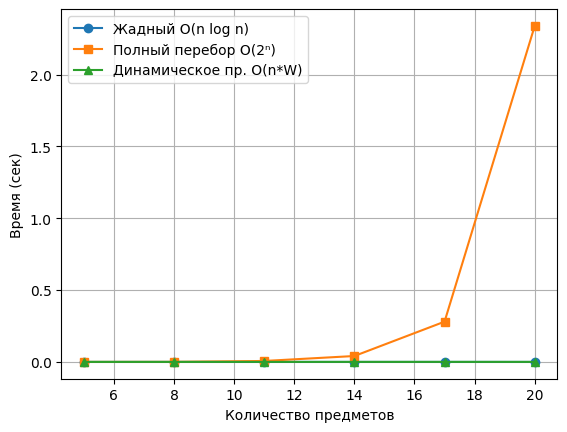

In [ ]:
# 2 задание (график)

import time
import itertools
import matplotlib.pyplot as plt
import random

# Жадный
def greedy(items, capacity):
    items_sorted = sorted(items, key=lambda x: x[1]/x[0], reverse=True)
    total_w = 0
    total_v = 0
    for w, v in items_sorted:
        if total_w + w <= capacity:
            total_w += w
            total_v += v
    return total_v

# Полный перебор
def brute_force(items, capacity):
    best = 0
    for r in range(1, len(items)+1):
        for combo in itertools.combinations(items, r):
            w = sum(x[0] for x in combo)
            if w <= capacity:
                v = sum(x[1] for x in combo)
                best = max(best, v)
    return best

# Динамическое программирование
def dp_knapsack(items, capacity):
    n = len(items)
    dp = [0]*(capacity+1)
    for w, v in items:
        for c in range(capacity, w-1, -1):
            dp[c] = max(dp[c], dp[c-w] + v)
    return dp[capacity]

def generate_items(n):
    return [(random.randint(1, 10), random.randint(1, 20)) for _ in range(n)]

sizes = range(5, 21, 3)
times_greedy = []
times_brute = []
times_dp = []

for n in sizes:
    items = generate_items(n)
    capacity = sum(w for w,_ in items) // 2

    t = time.perf_counter()
    greedy(items, capacity)
    times_greedy.append(time.perf_counter() - t)

    t = time.perf_counter()
    brute_force(items, capacity)
    times_brute.append(time.perf_counter() - t)

    t = time.perf_counter()
    dp_knapsack(items, capacity)
    times_dp.append(time.perf_counter() - t)

plt.figure()
plt.plot(sizes, times_greedy, 'o-', label='Жадный O(n log n)')
plt.plot(sizes, times_brute, 's-', label='Полный перебор O(2ⁿ)')
plt.plot(sizes, times_dp, '^-', label='Динамическое пр. O(n*W)')
plt.xlabel('Количество предметов')
plt.ylabel('Время (сек)')
plt.legend()
plt.grid()
plt.show()

# 3 задание

ничего не понял, решения нет ((

#4 задание

нет лекции

ничего не понял, решения нет, ничего нет ((

#5 задание

увы, но лекции как не было, так и нет..


#6 задание

увы, а вот это задание просто не получается (


#7 задание

увы, не пошло..



#8 задание

увы, увы, увы.

